# 03b · Heart-rate artifact screen (post hoc)

Phase 3 found that the alarm threshold sits at the edge of the training nights, and that a
likely measurement artifact (`Bidslab43/3`) helps set that edge. Phase 3b asks what a label-free
screen for such stretches changes. The protocol is decision 47 in `docs/decisions.md`, committed
before the rescoring.

- **Screen:** an epoch is *suspect* if its heart rate is at least 40 bpm above its night's median
  for at least 5 consecutive minutes. A missing epoch breaks a run.
- **Effect:** suspect epochs' heart rate is treated as missing everywhere the detector looks:
  priors, calibration nulls, personal baselines and test nights. Stages and movement are
  unchanged.
- **Method:** the Phase 3 run is *rescored*. Its stages, inner folds and injected nights are
  reused, so the screen is the only difference. Without the screen, the rescoring reproduces
  Phase 3's scores exactly (checked in the review notebook).

**This is post hoc.** The rule was chosen after seeing `Bidslab43/3`, so `anomaly_main` stays the
headline result and this is a sensitivity analysis. The notebook only reads saved runs.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sleepwatch.anomaly.experiment import AnomalyConfig
from sleepwatch.anomaly.scores import runs
from sleepwatch.anomaly.screen import suspect_night
from sleepwatch.config import get_settings
from sleepwatch.constants import EPOCH_S
from sleepwatch.features.build import load_build

settings = get_settings()
index = pd.read_csv(settings.results_dir / "anomaly_index.csv")


def latest(name):
    row = index[(index["name"] == name) & ~index["partial"]].iloc[-1]
    return settings.results_dir / name / row["run"]


main_dir, new_dir = latest("anomaly_main"), latest("anomaly_screened")
info = json.loads((new_dir / "run.json").read_text())
cfg = AnomalyConfig.from_yaml(new_dir / "config.yaml")
print(f"screened run {new_dir.name} at {info['git']['commit'][:8]}; dirty: {info['git']['dirty']}")
print(f"base run {info['base_run']['run']} at {info['base_run']['git']['commit'][:8]}")
assert info["git"]["dirty"] is False and info["base_run"]["run"] == main_dir.name
print("screen:", cfg.screen)

main_metrics = json.loads((main_dir / "metrics.json").read_text())
new_metrics = json.loads((new_dir / "metrics.json").read_text())
comparison = json.loads((new_dir / "comparison.json").read_text())
screened = pd.read_parquet(new_dir / "screened.parquet")
main_scores = pd.read_parquet(main_dir / "night_scores.parquet")
new_scores = pd.read_parquet(new_dir / "night_scores.parquet")
stages = pd.read_parquet(new_dir / "stages.parquet")
epochs, quality, _ = load_build(cfg.features, settings.processed_dir)

plt.rcParams.update(
    {
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.edgecolor": "#a9a8a3",
        "axes.labelcolor": "#52514e",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e1",
        "grid.linewidth": 0.6,
        "lines.linewidth": 1.2,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "font.size": 9,
        "legend.frameon": False,
    }
)
HEIGHT = np.array([4, 2, 1, 0, 3, np.nan])  # Wake, N1, N2, N3, REM, unknown -> plot rows


def ci(value, bounds, digits=3):
    return f"{value:+.{digits}f} [{bounds[0]:+.{digits}f}, {bounds[1]:+.{digits}f}]"

screened run 20261006T141555Z at 24081ef6; dirty: False
base run 20261006T091359Z at 93c9a177
screen: above_median_bpm=40.0 min_epochs=10


## 1 · What the screen marks

These are the clean nights with suspect epochs, out of all usable nights (baselines and test
nights alike). Each night is plotted with its epoch heart rate and expert stages, and the
suspect epochs are shaded. The expert stages are shown for description only; the screen never
sees them.

usable clean nights screened: 251


,subject,night,suspect_epochs,minutes,peak_bpm
1792,Bidslab43,3,82,41.0,172.3
2170,Bidslab53,3,12,6.0,124.1


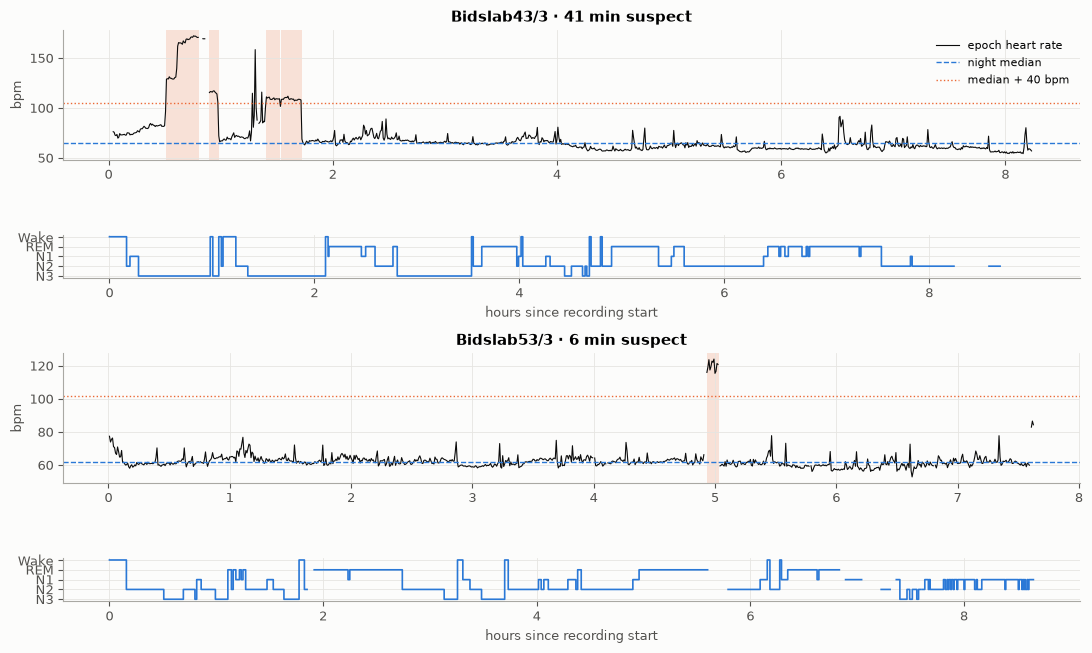

In [2]:
clean = screened[(screened["version"] == "clean") & (screened["suspect_epochs"] > 0)]
print(f"usable clean nights screened: {(screened['version'] == 'clean').sum()}")
display(clean[["subject", "night", "suspect_epochs", "minutes", "peak_bpm"]].round(1))

fig, axes = plt.subplots(
    2 * len(clean),
    1,
    figsize=(11, 3.3 * len(clean)),
    gridspec_kw={"height_ratios": [3, 1] * len(clean)},
)
for i, (_, row) in enumerate(clean.iterrows()):
    night = epochs[(epochs["subject"] == row["subject"]) & (epochs["night"] == row["night"])]
    night = night.sort_values("epoch")
    hr = night["hr_mean"].to_numpy()
    mask = suspect_night(hr, cfg.screen)
    hours = night["epoch"].to_numpy() * EPOCH_S / 3600
    ax, ax_stage = axes[2 * i], axes[2 * i + 1]
    ax.plot(hours, hr, color="#0b0b0b", lw=0.8, label="epoch heart rate")
    ax.axhline(np.nanmedian(hr), color="#2a78d6", lw=1, ls="--", label="night median")
    ax.axhline(
        np.nanmedian(hr) + cfg.screen.above_median_bpm,
        color="#eb6834",
        lw=1,
        ls=":",
        label=f"median + {cfg.screen.above_median_bpm:g} bpm",
    )
    for a, b in runs(mask):
        ax.axvspan(hours[a], hours[b - 1] + EPOCH_S / 3600, color="#eb6834", alpha=0.18, lw=0)
    ax.set(
        ylabel="bpm", title=f"{row['subject']}/{row['night']} · {row['minutes']:.0f} min suspect"
    )
    ax_stage.step(hours, HEIGHT[night["expert"].to_numpy()], where="post", color="#2a78d6")
    ax_stage.set_yticks([4, 3, 2, 1, 0], ["Wake", "REM", "N1", "N2", "N3"])
    ax_stage.set(xlabel="hours since recording start")
axes[0].legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

## 2 · Does the screen react to the injections?

It shouldn't. A +10 bpm injection or a copied awakening should not reach +40 bpm for 5 minutes.
For every injected version, the suspect epochs *outside* the injection windows should equal those
of the clean night. Inside a whole-night HR injection, the same epochs are marked, just shifted
up with the median.

In [3]:
injected = screened[screened["version"] != "clean"]
hit = injected[injected["suspect_epochs"] > 0]
nights_hit = sorted(set(zip(hit["subject"], hit["night"], strict=True)))
print(f"injected versions: {len(injected)}; with suspect epochs: {len(hit)}, on {nights_hit}")
off = injected[~injected["outside_matches_clean"]]
print(f"versions whose marks outside the injection windows differ from the clean night: {len(off)}")
display(off[["subject", "night", "version", "suspect_epochs", "inside_injection"]])
ref = screened[screened["version"] == "clean"].set_index(["subject", "night"])["suspect_epochs"]
off = off.assign(
    clean_suspect=[ref.loc[(s, n)] for s, n in zip(off["subject"], off["night"], strict=True)]
)
display(off[["version", "suspect_epochs", "clean_suspect"]])

injected versions: 2337; with suspect epochs: 30, on [('Bidslab43', 3), ('Bidslab53', 3)]
versions whose marks outside the injection windows differ from the clean night: 5


,subject,night,version,suspect_epochs,inside_injection
1794,Bidslab43,3,frag4,68,0
1795,Bidslab43,3,frag8,67,0
1796,Bidslab43,3,hr+10_120,64,0
1799,Bidslab43,3,hr+3_120,72,0
1802,Bidslab43,3,hr+6_120,72,0


,version,suspect_epochs,clean_suspect
1794,frag4,68,82
1795,frag8,67,82
1796,hr+10_120,64,82
1799,hr+3_120,72,82
1802,hr+6_120,72,82


All the mismatches are on `Bidslab43/3`, and they have two causes, both properties of the
rule:

- **Median shift.** The 2-h HR injections raise the night median by 1.6–3.2 bpm. That lifts
  the threshold from 104.6 to 106–108 bpm, and parts of the artifact's 106–117 bpm stretch fall
  below it, breaking runs to under 10 epochs.
- **Split runs.** In `frag4` and `frag8`, an inserted awakening lands *inside* the artifact
  stretch. The copied wake splits the run, and the pieces outside the window are under 10 epochs.

So 10–18 artifact epochs stay unmasked in those 5 versions. Section 4 shows what that does to
their flags.

## 3 · Main vs screened: false alarms, recall and AUROC

Primary detector (GRU stages, personal baseline). The difference is screened minus main, paired
by night version, with 95% CIs from resampling subjects.

,main,screened,difference [95% CI],nights up / down,AUROC main,AUROC screened
false alarms (clean),0.032,0.032,"+0.000 [-0.018, +0.019]",1 / 1,NaN,NaN
hr+3_30,0.032,0.032,"+0.000 [-0.018, +0.019]",1 / 1,0.504,0.505
hr+3_120,0.045,0.038,"-0.006 [-0.030, +0.013]",1 / 2,0.527,0.527
hr+3_sleep,0.045,0.045,"+0.000 [-0.018, +0.019]",1 / 1,0.596,0.597
hr+6_30,0.025,0.032,"+0.006 [+0.000, +0.020]",1 / 0,0.524,0.527
hr+6_120,0.038,0.038,"+0.000 [-0.018, +0.019]",1 / 1,0.585,0.591
hr+6_sleep,0.083,0.096,"+0.013 [-0.012, +0.037]",3 / 1,0.701,0.705
hr+10_30,0.045,0.045,"+0.000 [-0.018, +0.019]",1 / 1,0.583,0.588
hr+10_120,0.083,0.102,"+0.019 [+0.000, +0.043]",3 / 0,0.693,0.705
hr+10_sleep,0.274,0.287,"+0.013 [+0.000, +0.031]",2 / 0,0.824,0.830


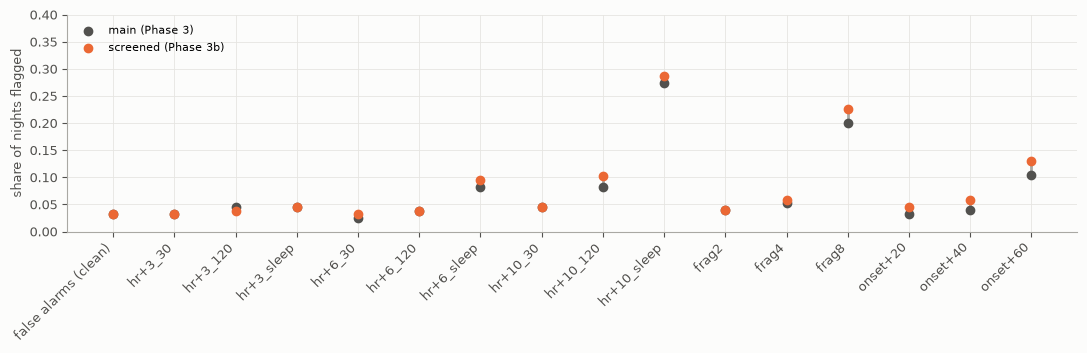

Screened minus main, all six detectors:


,expert/personal,expert/population,gru/personal,gru/population,none/personal,none/population
false alarms (clean),0.000,-0.006,0.000,0.006,-0.006,-0.006
hr+3_30,0.000,-0.006,0.000,0.006,-0.006,-0.006
hr+3_120,0.006,0.000,-0.006,0.000,0.000,-0.006
hr+3_sleep,0.000,0.000,0.000,0.000,0.000,-0.006
hr+6_30,0.000,-0.006,0.006,0.006,0.000,-0.006
hr+6_120,0.000,0.000,0.000,0.000,0.000,-0.006
hr+6_sleep,0.006,0.019,0.013,0.006,0.000,0.000
hr+10_30,0.006,0.006,0.000,0.006,-0.006,0.006
hr+10_120,0.006,0.019,0.019,0.006,0.006,0.013
hr+10_sleep,0.006,0.019,0.013,0.006,-0.019,0.000


In [4]:
primary = "gru/personal"
rows = []
for version, c in comparison["variants"][primary].items():
    m = main_metrics["variants"][primary]["conditions"].get(version, {})
    n = new_metrics["variants"][primary]["conditions"].get(version, {})
    rows.append(
        {
            "version": version,
            "main": round(c["base"], 3),
            "screened": round(c["new"], 3),
            "difference [95% CI]": ci(c["difference"], c["ci95"]),
            "nights up / down": f"{c['changed_up']} / {c['changed_down']}",
            "AUROC main": round(m["auroc"], 3) if m else None,
            "AUROC screened": round(n["auroc"], 3) if n else None,
        }
    )
order = ["clean", *main_metrics["variants"][primary]["conditions"]]
table = pd.DataFrame(rows).set_index("version").loc[order]
table.index = ["false alarms (clean)", *order[1:]]
display(table)

fig, ax = plt.subplots(figsize=(11, 3.6))
x = np.arange(len(table))
ax.vlines(x, table["main"], table["screened"], color="#a9a8a3", lw=2)
ax.scatter(x, table["main"], color="#52514e", zorder=3, label="main (Phase 3)")
ax.scatter(x, table["screened"], color="#eb6834", zorder=3, label="screened (Phase 3b)")
ax.set_xticks(x, table.index, rotation=45, ha="right")
ax.set(ylabel="share of nights flagged", ylim=(0, 0.4))
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

other = pd.DataFrame(
    {
        name: {v: round(c["difference"], 3) for v, c in entry.items()}
        for name, entry in comparison["variants"].items()
    }
).loc[order]
other.index = ["false alarms (clean)", *order[1:]]
print("Screened minus main, all six detectors:")
display(other)

## 4 · Where the changes come from

The alarm edge per fold: a test night must beat all but *k* of the *n* training nights in some
channel. After that, the flags of `Bidslab43/3`'s versions before and after the screen.

In [5]:
edge = pd.DataFrame(
    {label: pd.Series(values) for label, values in comparison["edge"].items()}
).rename(columns={"base": "main", "new": "screened"})
edge = edge[edge.index.str.startswith(primary)]
display(edge)

keys = ["subject", "night", "version"]
pick = (main_scores["source"] == "gru") & (main_scores["baseline"] == "personal")
pick_new = (new_scores["source"] == "gru") & (new_scores["baseline"] == "personal")
before = main_scores[pick & (main_scores["subject"] == "Bidslab43") & (main_scores["night"] == 3)]
after = new_scores[pick_new & (new_scores["subject"] == "Bidslab43") & (new_scores["night"] == 3)]
both = before[[*keys, "flagged", "top_channel", "hr_window"]].merge(
    after[[*keys, "flagged", "top_channel", "hr_window"]], on=keys, suffixes=(" main", " screened")
)
print(
    f"Bidslab43/3 versions flagged: main {int(both['flagged main'].sum())} of {len(both)}, "
    f"screened {int(both['flagged screened'].sum())} of {len(both)}"
)
display(both.drop(columns=["subject", "night"]).round(2))

,main,screened
gru/personal/0,0 of 120,1 of 120
gru/personal/1,1 of 124,1 of 124
gru/personal/2,1 of 126,1 of 126
gru/personal/3,0 of 129,0 of 129
gru/personal/4,0 of 129,0 of 129


Bidslab43/3 versions flagged: main 11 of 16, screened 3 of 16


,version,flagged main,top_channel main,hr_window main,flagged screened,top_channel screened,hr_window screened
0,clean,True,hr_window,4.97,False,onset,2.52
1,hr+3_30,True,hr_window,5.08,False,onset,2.52
2,hr+3_120,True,hr_window,9.37,False,hr_window,3.77
3,hr+3_sleep,True,hr_window,9.77,False,hr_window,3.14
4,hr+6_30,False,hr_window,4.74,False,onset,2.54
5,hr+6_120,True,hr_window,9.37,False,hr_window,3.77
6,hr+6_sleep,True,hr_window,5.08,False,hr_window,3.60
7,hr+10_30,True,hr_window,5.08,False,onset,2.52
8,hr+10_120,True,hr_window,9.37,True,hr_window,5.27
9,hr+10_sleep,True,hr_window,5.47,True,hr_night,4.33


## 5 · Real nights the detector flags

These are the clean test nights flagged by the primary detector, before and after the screen.

In [6]:
def flagged(scores, mask):
    part = scores[mask & (scores["version"] == "clean") & scores["flagged"]]
    return set(zip(part["subject"], part["night"], strict=True))


was, now = flagged(main_scores, pick), flagged(new_scores, pick_new)
print("flagged in both:", sorted(was & now))
print("only before the screen:", sorted(was - now))
print("only after the screen:", sorted(now - was))
summaries = json.loads((new_dir / "flagged_nights.json").read_text())
display(
    pd.DataFrame(
        [
            {
                "night": f"{f['subject']}/{f['night']}",
                "top channel": f["top_channel"],
                "window": "-".join(
                    (f[k] or "")[11:] for k in ("window_start_local", "window_end_local")
                ),
                "HR above expected (bpm)": None
                if f["hr_excess_bpm"] is None
                else round(f["hr_excess_bpm"], 1),
                "window stages": ", ".join(
                    f"{k} {v:.0%}" for k, v in f["window_stage_share"].items()
                ),
                "data quality": "; ".join(f["data_quality"]),
            }
            for f in summaries
        ]
    )
)

flagged in both: [('Bidslab11', 3), ('Bidslab22', 6), ('Bidslab32', 6), ('Bidslab66', 3)]
only before the screen: [('Bidslab43', 3)]
only after the screen: [('Bidslab34', 3)]


,night,top channel,window,HR above expected (bpm),window stages,data quality
0,Bidslab11/3,hr_window,23:04-23:34,19.8,N3 100%,
1,Bidslab22/6,hr_window,02:34-03:04,17.9,"N2 17%, N3 57%, REM 27%",
2,Bidslab66/3,hr_night,00:23-00:53,18.8,N3 100%,
3,Bidslab34/3,hr_window,22:56-23:26,33.4,"Wake 32%, N1 2%, N2 47%, N3 20%",
4,Bidslab32/6,onset,04:31-05:01,9.2,"N2 13%, N3 87%",


The new flag, `Bidslab34/3`, was the second most extreme night in its fold under Phase 3;
only `Bidslab43/3` beat it. Below are its heart rate, the GRU stages the detector used and
the expert stages, with the flagged window shaded.

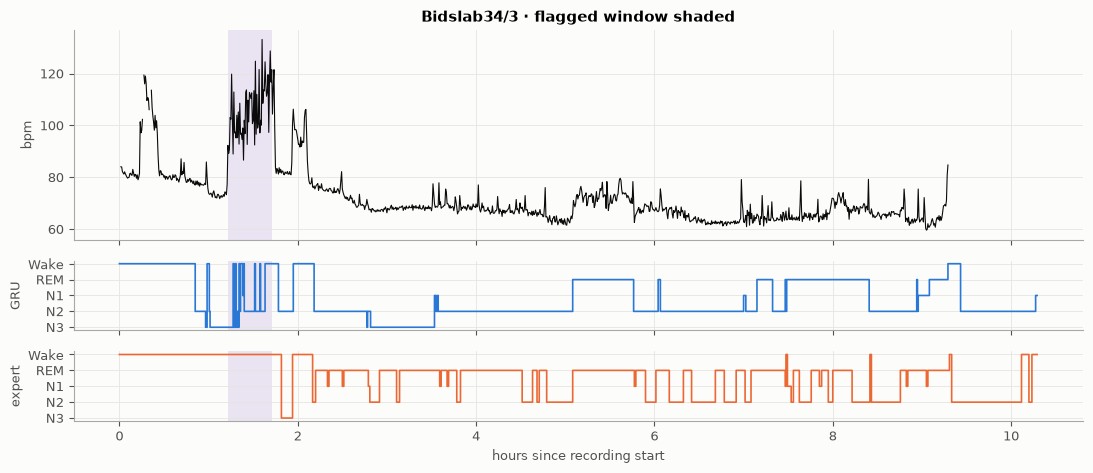

window: expert Wake 100%; GRU Wake 32%; epoch HR 87-133 bpm


In [7]:
night = epochs[(epochs["subject"] == "Bidslab34") & (epochs["night"] == 3)].sort_values("epoch")
summary = next(f for f in summaries if f["subject"] == "Bidslab34" and f["night"] == 3)
row = new_scores[
    pick_new
    & (new_scores["subject"] == "Bidslab34")
    & (new_scores["night"] == 3)
    & (new_scores["version"] == "clean")
].iloc[0]
a, b = json.loads(row["window"])
gru = stages[
    (stages["subject"] == "Bidslab34") & (stages["night"] == 3) & (stages["role"] == "test")
].sort_values("epoch")
hours = night["epoch"].to_numpy() * EPOCH_S / 3600
fig, (ax, ax_gru, ax_exp) = plt.subplots(
    3, 1, figsize=(11, 4.8), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1]}
)
ax.plot(hours, night["hr_mean"], color="#0b0b0b", lw=0.8)
for axis in (ax, ax_gru, ax_exp):
    axis.axvspan(a * EPOCH_S / 3600, b * EPOCH_S / 3600, color="#7e57c2", alpha=0.15, lw=0)
ax.set(ylabel="bpm", title="Bidslab34/3 · flagged window shaded")
ax_gru.step(hours, HEIGHT[gru["gru"].to_numpy()], where="post", color="#2a78d6")
ax_exp.step(hours, HEIGHT[night["expert"].to_numpy()], where="post", color="#eb6834")
for axis, label in ((ax_gru, "GRU"), (ax_exp, "expert")):
    axis.set_yticks([4, 3, 2, 1, 0], ["Wake", "REM", "N1", "N2", "N3"])
    axis.set_ylabel(label)
ax_exp.set(xlabel="hours since recording start")
plt.tight_layout()
plt.show()
window = night.iloc[a:b]
print(
    f"window: expert Wake {np.mean(window['expert'] == 0):.0%}; "
    f"GRU Wake {np.mean(gru['gru'].to_numpy()[a:b] == 0):.0%}; "
    f"epoch HR {window['hr_mean'].min():.0f}-{window['hr_mean'].max():.0f} bpm"
)

## 6 · Findings

1. **What the screen marks.** It marks 94 epochs on 2 of the 251 usable clean nights:
   - `Bidslab43/3`: 41 min, peak 172 bpm;
   - `Bidslab53/3`: 6 min, peak 124 bpm.

   Both show heart rate stepping up to a plateau and back while the EEG shows sleep. In the
   injected versions it marks epochs only on these two nights.
2. **One pre-declared check fails, on a single night.** In 5 of `Bidslab43/3`'s 15 injected
   versions, the marks outside the injection windows differ from the clean night's, and 10–18
   artifact epochs stay unmasked (section 2). The cause is the rule itself. Its median-relative
   threshold rises when a 2-h injection lifts the night median, and an awakening inserted
   inside the artifact splits its run below 5 min.
3. **The artifact is not what kept recall low.** For the primary detector:
   - **False alarms:** unchanged at 3.2%. One night left the flagged list and one joined it.
   - **Recall:** it moves by −0.006 to +0.026 per condition. The largest changes are 8
     awakenings +0.026 [+0.006, +0.053] and +60 min onset +0.026 [+0.006, +0.051]; whole-night
     +10 bpm is +0.013 [0.000, +0.031].
   - **AUROC:** it changes by at most 0.012.
   - **The other five detectors** move by at most 0.052, mostly under 0.02.

   Decision 46's diagnosis stands: the strict alarm edge and the natural night-to-night
   variation are the main limits.
4. **Where the small changes come from** (section 4). Two effects partly cancel:
   - **Fewer spurious hits.** In Phase 3 the artifact made 11 of `Bidslab43/3`'s 16 versions
     flag, whatever was injected. After the screen it is 3. One of them (`frag4`, via
     `hr_window`) comes from the unmasked remnant in point 2.
   - **A looser edge elsewhere.** Without the artifact among the training nights, fold 0's edge
     moves from "beat all 120" to "all but 1", and the `hr_window` maximum drops in folds 3 and
     4. Other nights cross the threshold more easily.
5. **Real flagged nights.** `Bidslab43/3` is no longer flagged. `Bidslab34/3` is newly flagged;
   under Phase 3 only `Bidslab43/3` had beaten it.
   - **Expert labels:** the person was awake for the whole flagged window, and for the first
     1.8 h of the recording.
   - **GRU:** it staged most of that window as N2/N3, so the detector compared waking heart rate
     (87–133 bpm) with sleep-level expectations.

   So a staging error can also produce a flag. That is a limit of the stage-based detector, not
   something the screen addresses. No flagged night has suspect epochs, so no summary carries
   the new data-quality note. Both screened nights are listed in `screened.parquet` for a
   data-quality notice.

**Limits.**
- **Post hoc rule:** it was chosen after seeing `Bidslab43/3`.
- **Artifact or tachycardia:** it can't tell a sensor artifact from a real abrupt tachycardia.
- **Stages unchanged:** the stages still come from a GRU that saw the artifact.
- **Interaction with injections:** on artifact nights the rule interacts with injections
  (point 2).

**Headline:** `anomaly_main` stays the headline result; this run is a sensitivity analysis.